<a href="https://colab.research.google.com/github/SaimNaveed646/ML_Models/blob/main/Numpy/numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What is Numpy?

NumPy is the fundamental package for scientific computing in Python. It is a Python library that provides a multidimensional array object, various derived objects (such as masked arrays and matrices), and an assortment of routines for fast operations on arrays, including mathematical, logical, shape manipulation, sorting, selecting, I/O, discrete Fourier transforms, basic linear algebra, basic statistical operations, random simulation and much more.

At the core of the NumPy package, is the ndarray object. This encapsulates n-dimensional arrays of homogeneous data types, with many operations being performed in compiled code for performance. There are several important differences between NumPy arrays and the standard Python sequences:



*   NumPy arrays have a fixed size at creation, unlike Python lists (which can grow dynamically). Changing the size of an ndarray will create a new array and delete the original.
*   The elements in a NumPy array are all required to be of the same data type, and thus will be the same size in memory. The exception: one can have arrays of (Python, including NumPy) objects, thereby allowing for arrays of different sized elements.
*   NumPy arrays facilitate advanced mathematical and other types of operations on large numbers of data. Typically, such operations are executed more efficiently and with less code than is possible using Python’s built-in sequences.
*   A growing plethora of scientific and mathematical Python-based packages are using NumPy arrays; though these typically support Python-sequence input, they convert such input to NumPy arrays prior to processing, and they often output NumPy arrays. In other words, in order to efficiently use much (perhaps even most) of today’s scientific/mathematical Python-based software, just knowing how to use Python’s built-in sequence types is insufficient - one also needs to know how to use NumPy arrays.



The points about sequence size and speed are particularly important in scientific computing. As a simple example, consider the case of multiplying each element in a 1-D sequence with the corresponding element in another sequence of the same length. If the data are stored in two Python lists, a and b, we could iterate over each element:

In [ ]:
# c = []
# for i in range(len(a)):
#     c.append(a[i]*b[i])

This produces the correct answer, but if a and b each contain millions of numbers, we will pay the price for the inefficiencies of looping in Python. We could accomplish the same task much more quickly in C by writing (for clarity we neglect variable declarations and initializations, memory allocation, etc.)

In [ ]:
# for (i = 0; i < rows; i++) {
#   c[i] = a[i]*b[i];
# }

This saves all the overhead involved in interpreting the Python code and manipulating Python objects, but at the expense of the benefits gained from coding in Python. Furthermore, the coding work required increases with the dimensionality of our data. In the case of a 2-D array, for example, the C code (abridged as before) expands to

In [ ]:
# for (i = 0; i < rows; i++) {
#   for (j = 0; j < columns; j++) {
#     c[i][j] = a[i][j]*b[i][j];
#   }
# }

NumPy gives us the best of both worlds: element-by-element operations are the “default mode” when an ndarray is involved, but the element-by-element operation is speedily executed by pre-compiled C code. In NumPy

In [ ]:
# c = a * b

does what the earlier examples do, at near-C speeds, but with the code simplicity we expect from something based on Python. Indeed, the NumPy idiom is even simpler! This last example illustrates two of NumPy’s features which are the basis of much of its power: vectorization and broadcasting.

# Why is NumPy fast?
Vectorization describes the absence of any explicit looping, indexing, etc., in the code - these things are taking place, of course, just “behind the scenes” in optimized, pre-compiled C code. Vectorized code has many advantages, among which are:





*   vectorized code is more concise and easier to read
*   fewer lines of code generally means fewer bugs
*   the code more closely resembles standard mathematical notation (making it easier, typically, to correctly code mathematical constructs)
*   vectorization results in more “Pythonic” code. Without vectorization, our code would be littered with inefficient and difficult to read for loops.









Broadcasting is the term used to describe the implicit element-by-element behavior of operations; generally speaking, in NumPy all operations, not just arithmetic operations, but logical, bit-wise, functional, etc., behave in this implicit element-by-element fashion, i.e., they broadcast. Moreover, in the example above, a and b could be multidimensional arrays of the same shape, or a scalar and an array, or even two arrays with different shapes, provided that the smaller array is “expandable” to the shape of the larger in such a way that the resulting broadcast is unambiguous.

# Array creation

In [ ]:
a = np.array([1,2,3])


In [ ]:
a

array([1, 2, 3])

In [ ]:
a.dtype

dtype('int64')

The type of the resulting array is deduced from the type of the elements in the sequences.

In [ ]:
b = np.array([1.0,2.0,3.0])


In [ ]:
b.dtype

dtype('float64')

A frequent error consists in calling array with multiple arguments, rather than providing a single sequence as an argument.

In [ ]:
a = np.array(1,2,3,4)

TypeError: array() takes from 1 to 2 positional arguments but 4 were given

In [ ]:
a = np.array([1,2,3,4])

array transforms sequences of sequences into two-dimensional arrays, sequences of sequences of sequences into three-dimensional arrays, and so on.

In [ ]:
a = np.array([(1,2,3),(1.5,3,4)])

In [ ]:
a

array([[1. , 2. , 3. ],
       [1.5, 3. , 4. ]])

In [ ]:
a.dtype

dtype('float64')

In [ ]:
a.ndim

2

In [ ]:
a.shape

(2, 3)

The type of the array can also be explicitly specified at creation time:

In [ ]:
c = np.array([(1, 2), (3, 4)], dtype=complex)
c

array([[1.+0.j, 2.+0.j],
       [3.+0.j, 4.+0.j]])

Often, the elements of an array are originally unknown, but its size is known. Hence, NumPy offers several functions to create arrays with initial placeholder content. These minimize the necessity of growing arrays, an expensive operation.
The function zeros creates an array full of zeros, the function ones creates an array full of ones, and the function empty creates an array whose initial content is random and depends on the state of the memory. By default, the dtype of the created array is float64, but it can be specified via the key word argument dtype.

In [ ]:
np.zeros((3,4))

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [ ]:
a = np.ones((2,3,4),dtype=np.int64)

In [ ]:
a.shape


(2, 3, 4)

In [ ]:
np.ones((2,3,4),dtype=np.int64)

array([[[1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1]],

       [[1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1]]])

In [ ]:
np.empty((2, 3))

array([[1. , 2. , 3. ],
       [1.5, 3. , 4. ]])

To create sequences of numbers, NumPy provides the arange function which is analogous to the Python built-in range, but returns an array.

In [ ]:
np.arange(10,30,5)

array([10, 15, 20, 25])

In [ ]:
np.arange(10,30,2)

array([10, 12, 14, 16, 18, 20, 22, 24, 26, 28])

In [ ]:
np.arange(10,30,1)

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29])

When arange is used with floating point arguments, it is generally not possible to predict the number of elements obtained, due to the finite floating point precision. For this reason, it is usually better to use the function linspace that receives as an argument the number of elements that we want, instead of the step:

In [ ]:
from numpy import pi

In [ ]:
np.linspace(0, 2, 9)

array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  ])

In [ ]:
x = np.linspace(0, 2 * pi, 100)

In [ ]:
f = np.sin(x)

# Printing arrays

When you print an array, NumPy displays it in a similar way to nested lists, but with the following layout:



*   the last axis is printed from left to right
*   the second-to-last is printed from top to bottom
*   the rest are also printed from top to bottom, with each slice separated from the next by an empty line.



One-dimensional arrays are then printed as rows, bidimensionals as matrices and tridimensionals as lists of matrices.

In [ ]:
a = np.arange(6)
print(a)

[0 1 2 3 4 5]


In [ ]:
b = np.arange(12).reshape(4, 3)
print(b)

[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


In [ ]:
c = np.arange(24).reshape(2, 3, 4)
print(c)

[[[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]

 [[12 13 14 15]
  [16 17 18 19]
  [20 21 22 23]]]


If an array is too large to be printed, NumPy automatically skips the central part of the array and only prints the corners:

In [ ]:
print(np.arange(10000))

[   0    1    2 ... 9997 9998 9999]


In [ ]:
print(np.arange(10000).reshape(100, 100))

[[   0    1    2 ...   97   98   99]
 [ 100  101  102 ...  197  198  199]
 [ 200  201  202 ...  297  298  299]
 ...
 [9700 9701 9702 ... 9797 9798 9799]
 [9800 9801 9802 ... 9897 9898 9899]
 [9900 9901 9902 ... 9997 9998 9999]]


To disable this behaviour and force NumPy to print the entire array, you can change the printing options using set_printoptions.

In [ ]:
# np.set_printoptions(threshold=sys.maxsize)

# Basic operations

Arithmetic operators on arrays apply elementwise. A new array is created and filled with the result.

In [ ]:
a = np.array([10,20,30,40])

In [ ]:
b = np.arange(4)

In [ ]:
c = a-b

In [ ]:
c

array([10, 19, 28, 37])

In [ ]:
b**2

array([0, 1, 4, 9])

In [ ]:
10 * np.sin(a)

array([-5.44021111,  9.12945251, -9.88031624,  7.4511316 ])

In [ ]:
a < 35

array([ True,  True,  True, False])

Unlike in many matrix languages, the product operator * operates elementwise in NumPy arrays. The matrix product can be performed using the @ operator (in python >=3.5) or the dot function or method:

In [ ]:
A = np.array([[1, 1],
              [0, 1]])

In [ ]:
B = np.array([[2, 0],
              [3, 4]])

In [ ]:
A * B

array([[2, 0],
       [0, 4]])

In [ ]:
A @ B

array([[5, 4],
       [3, 4]])

In [ ]:
A.dot(B)

array([[5, 4],
       [3, 4]])

Some operations, such as += and *=, act in place to modify an existing array rather than create a new one.

In [ ]:
rg = np.random.default_rng(1)

In [ ]:
a = np.ones((2, 3), dtype=int)

In [ ]:
b = rg.random((2, 3))

In [ ]:
a *= 3

In [ ]:
a

array([[3, 3, 3],
       [3, 3, 3]])

In [ ]:
b += a
b

array([[3.51182162, 3.9504637 , 3.14415961],
       [3.94864945, 3.31183145, 3.42332645]])

In [ ]:
a +=b # b is not automatically converted to integer type

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int64') with casting rule 'same_kind'

When operating with arrays of different types, the type of the resulting array corresponds to the more general or precise one (a behavior known as upcasting).

In [ ]:
a = np.ones(3, dtype=np.int32)

In [ ]:
a.dtype.name

'int32'

In [ ]:
a

array([1, 1, 1], dtype=int32)

In [ ]:
b = np.linspace(0, pi, 3)

In [ ]:
b

array([0.        , 1.57079633, 3.14159265])

In [ ]:
b.dtype.name

'float64'

In [ ]:
c = a+b
c

array([1.        , 2.57079633, 4.14159265])

In [ ]:
c.dtype.name

'float64'

In [ ]:
d = np.exp(c * 1j)
d.dtype.name

'complex128'

In [ ]:
d

array([ 0.54030231+0.84147098j, -0.84147098+0.54030231j,
       -0.54030231-0.84147098j])

Many unary operations, such as computing the sum of all the elements in the array, are implemented as methods of the ndarray class.

In [ ]:
a = rg.random((2, 3))

In [ ]:
a

array([[0.82770259, 0.40919914, 0.54959369],
       [0.02755911, 0.75351311, 0.53814331]])

In [ ]:
a.sum()

np.float64(3.1057109529998157)

In [ ]:
print(a.min())

0.027559113243068367


In [ ]:
a.max()

np.float64(0.8277025938204418)

By default, these operations apply to the array as though it were a list of numbers, regardless of its shape. However, by specifying the axis parameter you can apply an operation along the specified axis of an array:

In [ ]:
b = np.arange(12).reshape(3, 4)
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [ ]:
b.sum(axis=0)     # sum of each column

array([12, 15, 18, 21])

In [ ]:
b.min(axis=1)     # min of each row

array([0, 4, 8])

In [ ]:
b.cumsum(axis=1)  # cumulative sum along each row

array([[ 0,  1,  3,  6],
       [ 4,  9, 15, 22],
       [ 8, 17, 27, 38]])

# Universal functions
NumPy provides familiar mathematical functions such as sin, cos, and exp. In NumPy, these are called “universal functions” (ufunc). Within NumPy, these functions operate elementwise on an array, producing an array as output.

In [ ]:
B = np.arange(3)
B

array([0, 1, 2])

In [ ]:
np.exp(B)

array([1.        , 2.71828183, 7.3890561 ])

In [ ]:
np.sqrt(B)

array([0.        , 1.        , 1.41421356])

In [ ]:
C = np.array([2., -1., 4.])

In [ ]:
np.add(B, C)

array([2., 0., 6.])

# Indexing, slicing and iterating
One-dimensional arrays can be indexed, sliced and iterated over, much like lists and other Python sequences.

In [ ]:
a = np.arange(10)**3
a

array([  0,   1,   8,  27,  64, 125, 216, 343, 512, 729])

In [ ]:
a[2]

np.int64(8)

In [ ]:
a[2:5]

array([ 8, 27, 64])

In [ ]:
# from start to position 6, exclusive, set every 2nd element to 1000
a[0:6:2] = 1000; # a[:6:2] = 1000
a

array([1000,    1, 1000,   27, 1000,  125,  216,  343,  512,  729])

In [ ]:
a[::-1]  # reversed a

array([ 729,  512,  343,  216,  125, 1000,   27, 1000,    1, 1000])

In [ ]:
for i in a:

    print(i**(1 / 3.))

9.999999999999998
1.0
9.999999999999998
3.0
9.999999999999998
4.999999999999999
5.999999999999999
6.999999999999999
7.999999999999999
8.999999999999998


Multidimensional arrays can have one index per axis. These indices are given in a tuple separated by commas:

In [ ]:
def f(x, y):
    return 10 * x + y

This line uses NumPy’s fromfunction to create an array by calling a function f on index coordinates.

In [ ]:
b = np.fromfunction(f, (5, 4), dtype=int)

For a 2D array of shape (5, 4), NumPy calls:
f(i, j)
where:

x = row indices → 0, 1, 2, 3, 4

y = column indices → 0, 1, 2, 3

These indices are passed as NumPy arrays, not scalars.

Step-by-step rows

Row 0 (x = 0): 10*0 + y → [0, 1, 2, 3]

Row 1 (x = 1): 10*1 + y → [10, 11, 12, 13]

Row 2 (x = 2): 10*2 + y → [20, 21, 22, 23]

Row 3 (x = 3): 10*3 + y → [30, 31, 32, 33]

Row 4 (x = 4): 10*4 + y → [40, 41, 42, 43]

In [ ]:
b

array([[ 0,  1,  2,  3],
       [10, 11, 12, 13],
       [20, 21, 22, 23],
       [30, 31, 32, 33],
       [40, 41, 42, 43]])

In [ ]:
b[2, 3]

np.int64(23)

In [ ]:
b[0:5, 1]  # each row in the second column of b

array([ 1, 11, 21, 31, 41])

In [ ]:
b[:, 1]    # equivalent to the previous example

array([ 1, 11, 21, 31, 41])

In [ ]:
b[1:3, :]  # each column in the second and third row of b

array([[10, 11, 12, 13],
       [20, 21, 22, 23]])

When fewer indices are provided than the number of axes, the



missing indices are considered complete slices:

In [ ]:
b[-1]   # the last row. Equivalent to b[-1, :]

array([40, 41, 42, 43])

The expression within brackets in b[i] is treated as an i followed by as many instances of : as needed to represent the remaining axes. NumPy also allows you to write this using dots as b[i, ...].

The dots (...) represent as many colons as needed to produce a complete indexing tuple. For example, if x is an array with 5 axes, then

x[1, 2, ...] is equivalent to x[1, 2, :, :, :],

x[..., 3] to x[:, :, :, :, 3] and

x[4, ..., 5, :] to x[4, :, :, 5, :].

In [ ]:
b[-1,...]

array([40, 41, 42, 43])

In [ ]:
c = np.array([[[  0,  1,  2],  # a 3D array (two stacked 2D arrays)
               [ 10, 12, 13]],
              [[100, 101, 102],
               [110, 112, 113]]])

In [ ]:
c.shape

(2, 2, 3)

In [ ]:
c[1, ...]  # same as c[1, :, :] or c[1]

array([[100, 101, 102],
       [110, 112, 113]])

In [ ]:
c[..., 2]  # same as c[:, :, 2]

array([[  2,  13],
       [102, 113]])

Iterating over multidimensional arrays is done with respect to the first axis:

In [ ]:
b

array([[ 0,  1,  2,  3],
       [10, 11, 12, 13],
       [20, 21, 22, 23],
       [30, 31, 32, 33],
       [40, 41, 42, 43]])

In [ ]:
for row in b:
    print(row)

[0 1 2 3]
[10 11 12 13]
[20 21 22 23]
[30 31 32 33]
[40 41 42 43]


However, if one wants to perform an operation on each element in the array, one can use the flat attribute which is an iterator over all the elements of the array:

In [ ]:
for element in b.flat:
    print(element)

0
1
2
3
10
11
12
13
20
21
22
23
30
31
32
33
40
41
42
43


# Shape manipulation
# Changing the shape of an array
An array has a shape given by the number of elements along each axis:

In [ ]:
a = np.floor(10 * rg.random((3, 4)))
print(a)
a.shape

[[0. 5. 4. 0.]
 [6. 8. 5. 2.]
 [8. 5. 5. 7.]]


(3, 4)

The shape of an array can be changed with various commands. Note that the following three commands all return a modified array, but do not change the original array:

In [ ]:
b=a.ravel()  # returns the array, flattened

In [ ]:
b

array([0., 5., 4., 0., 6., 8., 5., 2., 8., 5., 5., 7.])

In [ ]:
a

array([[0., 5., 4., 0.],
       [6., 8., 5., 2.],
       [8., 5., 5., 7.]])

In [ ]:
a.reshape(6, 2)  # returns the array with a modified shape

array([[0., 5.],
       [4., 0.],
       [6., 8.],
       [5., 2.],
       [8., 5.],
       [5., 7.]])

In [ ]:
a

array([[0., 5., 4., 0.],
       [6., 8., 5., 2.],
       [8., 5., 5., 7.]])

In [ ]:
a.T  # returns the array, transposed

array([[0., 6., 8.],
       [5., 8., 5.],
       [4., 5., 5.],
       [0., 2., 7.]])

In [ ]:
a.T.shape  # returns the array, transposed

(4, 3)

In [ ]:
a.shape

(3, 4)

The reshape function returns its argument with a modified shape, whereas the ndarray.resize method modifies the array itself:

In [ ]:
a

array([[0., 5., 4., 0.],
       [6., 8., 5., 2.],
       [8., 5., 5., 7.]])

In [ ]:
a.resize((2, 6))
a

array([[0., 5., 4., 0., 6., 8.],
       [5., 2., 8., 5., 5., 7.]])

If a dimension is given as -1 in a reshaping operation, the other dimensions are automatically calculated:

In [ ]:
a.reshape(3, -1)

array([[0., 5., 4., 0.],
       [6., 8., 5., 2.],
       [8., 5., 5., 7.]])


# Stacking together different arrays

Several arrays can be stacked together along different axes:

In [ ]:
a = np.floor(10 * rg.random((2, 2)))
a

array([[1., 8.],
       [1., 0.]])

In [ ]:
b = np.floor(10 * rg.random((2, 2)))
b

array([[8., 8.],
       [8., 4.]])

In [ ]:
np.vstack((a, b)) #vertically stack

array([[1., 8.],
       [1., 0.],
       [8., 8.],
       [8., 4.]])

In [ ]:
np.hstack((a, b)) #horizontal stack

array([[1., 8., 8., 8.],
       [1., 0., 8., 4.]])

The function column_stack stacks 1D arrays as columns into a 2D array. It is equivalent to hstack only for 2D arrays:

In [ ]:
np.column_stack((a, b))  # with 2D arrays

array([[1., 8., 8., 8.],
       [1., 0., 8., 4.]])

In [ ]:
a = np.array([4., 2.])

In [ ]:
b = np.array([3., 8.])

In [ ]:
np.column_stack((a, b))

array([[4., 3.],
       [2., 8.]])

In [ ]:
np.hstack((a, b))        # the result is different

array([4., 2., 3., 8.])

In [ ]:
from numpy import newaxis
a[:, newaxis]  # view `a` as a 2D column vector

array([[4.],
       [2.]])

In [ ]:
np.column_stack((a[:, newaxis], b[:, newaxis]))

array([[4., 3.],
       [2., 8.]])

In [ ]:
np.hstack((a[:, newaxis], b[:, newaxis]))  # the result is the same

array([[4., 3.],
       [2., 8.]])

In general, for arrays with more than two dimensions, hstack stacks along their second axes, vstack stacks along their first axes

# Splitting one array into several smaller ones

Using hsplit, you can split an array along its horizontal axis, either by specifying the number of equally shaped arrays to return, or by specifying the columns after which the division should occur:

In [ ]:
import numpy as np

In [ ]:
rg = np.random.default_rng(1)

In [ ]:
a = np.floor(10 * rg.random((2, 12)))
a

array([[5., 9., 1., 9., 3., 4., 8., 4., 5., 0., 7., 5.],
       [3., 7., 3., 4., 1., 4., 2., 2., 7., 2., 4., 9.]])

In [ ]:
np.hsplit(a, 3) # Split `a` into 3

[array([[5., 9., 1., 9.],
        [3., 7., 3., 4.]]),
 array([[3., 4., 8., 4.],
        [1., 4., 2., 2.]]),
 array([[5., 0., 7., 5.],
        [7., 2., 4., 9.]])]

In [ ]:
np.hsplit(a, (3, 4)) # Split `a` after the third and the fourth column

[array([[5., 9., 1.],
        [3., 7., 3.]]),
 array([[9.],
        [4.]]),
 array([[3., 4., 8., 4., 5., 0., 7., 5.],
        [1., 4., 2., 2., 7., 2., 4., 9.]])]

vsplit splits along the vertical axis, and array_split allows one to specify along which axis to split.

# Copies and views

When operating and manipulating arrays, their data is sometimes copied into a new array and sometimes not. This is often a source of confusion for beginners. There are three cases:

# No copy at all

Simple assignments make no copy of objects or their data.

In [ ]:
a = np.array([[ 0,  1,  2,  3],
              [ 4,  5,  6,  7],
              [ 8,  9, 10, 11]])

In [ ]:
b = a            # no new object is created

In [ ]:
b is a           # a and b are two names for the same ndarray object

True

Python passes mutable objects as references, so function calls make no copy.


In [ ]:
def f(x):
    print(id(x))

In [ ]:
id(a)

132253242592688

In [ ]:
f(a)

132253242592688


# View or shallow copy

Different array objects can share the same data. The view method creates a new array object that looks at the same data.

In [ ]:
c = a.view()

In [ ]:
c is a

False

In [ ]:
c.base is a            # c is a view of the data owned by a

True

In [ ]:
c.flags.owndata

False

In [ ]:
c = c.reshape((2, 6))  # a's shape doesn't change, reassigned c is still a view of a

In [ ]:
a.shape

(3, 4)

In [ ]:
c[0, 4] = 1234         # a's data changes

In [ ]:
a

array([[   0,    1,    2,    3],
       [1234,    5,    6,    7],
       [   8,    9,   10,   11]])

Slicing an array returns a view of it:

In [ ]:
s = a[:, 1:3]

In [ ]:
s[:] = 10  # s[:] is a view of s. Note the difference between s = 10 and s[:] = 10

In [ ]:
a

array([[   0,   10,   10,    3],
       [1234,   10,   10,    7],
       [   8,   10,   10,   11]])

# Deep copy

The copy method makes a complete copy of the array and its data.

In [ ]:
d = a.copy()  # a new array object with new data is created

In [ ]:
d is a

False

In [ ]:
d.base is a  # d doesn't share anything with a

False

In [ ]:
d[0, 0] = 9999

In [ ]:
a

array([[   0,   10,   10,    3],
       [1234,   10,   10,    7],
       [   8,   10,   10,   11]])

Sometimes copy should be called after slicing if the original array is not required anymore. For example, suppose a is a huge intermediate result and the final result b only contains a small fraction of a, a deep copy should be made when constructing b with slicing:

In [ ]:
a = np.arange(int(1e8))
b = a[:100].copy()
del a  # the memory of ``a`` can be released.

If b = a[:100] is used instead, a is referenced by b and will persist in memory even if del a is executed.

# Functions and methods overview
Here is a list of some useful NumPy functions and methods names ordered in categories.

# Array Creation
arange, array, copy, empty, empty_like, eye, fromfile, fromfunction, identity, linspace, logspace, mgrid, ogrid, ones, ones_like, r_, zeros, zeros_like

# Conversions
ndarray.astype, atleast_1d, atleast_2d, atleast_3d, mat

# Manipulations
array_split, column_stack, concatenate, diagonal, dsplit, dstack, hsplit, hstack, ndarray.item, newaxis, ravel, repeat, reshape, resize, squeeze, swapaxes, take, transpose, vsplit, vstack

# Questions
all, any, nonzero, where

# Ordering
argmax, argmin, argsort, max, min, ptp, searchsorted, sort

# Operations
choose, compress, cumprod, cumsum, inner, ndarray.fill, imag, prod, put, putmask, real, sum

# Basic Statistics
cov, mean, std, var

# Basic Linear Algebra
cross, dot, outer, linalg.svd, vdot

# Broadcasting rules

Broadcasting allows universal functions to deal in a meaningful way with inputs that do not have exactly the same shape.

The first rule of broadcasting is that if all input arrays do not have the same number of dimensions, a “1” will be repeatedly prepended to the shapes of the smaller arrays until all the arrays have the same number of dimensions.

The second rule of broadcasting ensures that arrays with a size of 1 along a particular dimension act as if they had the size of the array with the largest shape along that dimension. The value of the array element is assumed to be the same along that dimension for the “broadcast” array.

After application of the broadcasting rules, the sizes of all arrays must match.

The term broadcasting describes how NumPy treats arrays with different shapes during arithmetic operations. Subject to certain constraints, the smaller array is “broadcast” across the larger array so that they have compatible shapes. Broadcasting provides a means of vectorizing array operations so that looping occurs in C instead of Python. It does this without making needless copies of data and usually leads to efficient algorithm implementations. There are, however, cases where broadcasting is a bad idea because it leads to inefficient use of memory that slows computation.

NumPy operations are usually done on pairs of arrays on an element-by-element basis. In the simplest case, the two arrays must have exactly the same shape, as in the following example:

In [ ]:
import numpy as np
a = np.array([1.0, 2.0, 3.0])
b = np.array([2.0, 2.0, 2.0])
a * b

array([2., 4., 6.])

NumPy’s broadcasting rule relaxes this constraint when the arrays’ shapes meet certain constraints. The simplest broadcasting example occurs when an array and a scalar value are combined in an operation:

In [ ]:
import numpy as np
a = np.array([1.0, 2.0, 3.0])
b = 2.0
a * b

array([2., 4., 6.])

The result is equivalent to the previous example where b was an array. We can think of the scalar b being stretched during the arithmetic operation into an array with the same shape as a. The new elements in b, as shown in Figure 1, are simply copies of the original scalar. The stretching analogy is only conceptual. NumPy is smart enough to use the original scalar value without actually making copies so that broadcasting operations are as memory and computationally efficient as possible.

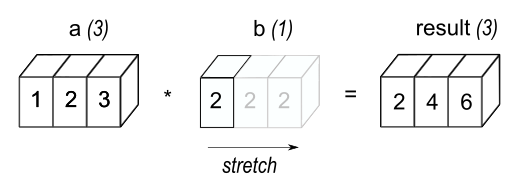

The code in the second example is more efficient than that in the first because broadcasting moves less memory around during the multiplication (b is a scalar rather than an array).

# General broadcasting rules

When operating on two arrays, NumPy compares their shapes element-wise. It starts with the trailing (i.e. rightmost) dimension and works its way left. Two dimensions are compatible when



*   they are equal, or
*   one of them is 1.





If these conditions are not met, a ValueError: operands could not be broadcast together exception is thrown, indicating that the arrays have incompatible shapes.

Input arrays do not need to have the same number of dimensions. The resulting array will have the same number of dimensions as the input array with the greatest number of dimensions, where the size of each dimension is the largest size of the corresponding dimension among the input arrays. Note that missing dimensions are assumed to have size one.

For example, if you have a 256x256x3 array of RGB values, and you want to scale each color in the image by a different value, you can multiply the image by a one-dimensional array with 3 values. Lining up the sizes of the trailing axes of these arrays according to the broadcast rules, shows that they are compatible:

In [ ]:
# Image  (3d array): 256 x 256 x 3
# Scale  (1d array):             3
# Result (3d array): 256 x 256 x 3

When either of the dimensions compared is one, the other is used. In other words, dimensions with size 1 are stretched or “copied” to match the other.

In the following example, both the A and B arrays have axes with length one that are expanded to a larger size during the broadcast operation:

In [ ]:
# A      (4d array):  8 x 1 x 6 x 1
# B      (3d array):      7 x 1 x 5
# Result (4d array):  8 x 7 x 6 x 5

# Broadcastable arrays
A set of arrays is called “broadcastable” to the same shape if the above rules produce a valid result.

For example, if a.shape is (5,1), b.shape is (1,6), c.shape is (6,) and d.shape is () so that d is a scalar, then a, b, c, and d are all broadcastable to dimension (5,6); and




*   a acts like a (5,6) array where a[:,0] is broadcast to the other columns,
*   b acts like a (5,6) array where b[0,:] is broadcast to the other rows,
*   c acts like a (1,6) array and therefore like a (5,6) array where c[:] is broadcast to every row, and finally,
*   d acts like a (5,6) array where the single value is repeated.








Here are some more examples:



In [ ]:
# A      (2d array):  5 x 4
# B      (1d array):      1
# Result (2d array):  5 x 4

# A      (2d array):  5 x 4
# B      (1d array):      4
# Result (2d array):  5 x 4

# A      (3d array):  15 x 3 x 5
# B      (3d array):  15 x 1 x 5
# Result (3d array):  15 x 3 x 5

# A      (3d array):  15 x 3 x 5
# B      (2d array):       3 x 5
# Result (3d array):  15 x 3 x 5

# A      (3d array):  15 x 3 x 5
# B      (2d array):       3 x 1
# Result (3d array):  15 x 3 x 5

Here are examples of shapes that do not broadcast:



In [ ]:
# A      (1d array):  3
# B      (1d array):  4 # trailing dimensions do not match

# A      (2d array):      2 x 1
# B      (3d array):  8 x 4 x 3 # second from last dimensions mismatched

An example of broadcasting when a 1-d array is added to a 2-d array:

In [ ]:
import numpy as np
a = np.array([[ 0.0,  0.0,  0.0],
              [10.0, 10.0, 10.0],
              [20.0, 20.0, 20.0],
              [30.0, 30.0, 30.0]])
b = np.array([1.0, 2.0, 3.0])
print(a.shape)
print(b.shape)
print(a + b)
b = np.array([1.0, 2.0, 3.0, 4.0])
print(a.shape)
print(b.shape)
print(a + b)

(4, 3)
(3,)
[[ 1.  2.  3.]
 [11. 12. 13.]
 [21. 22. 23.]
 [31. 32. 33.]]
(4, 3)
(4,)


ValueError: operands could not be broadcast together with shapes (4,3) (4,) 

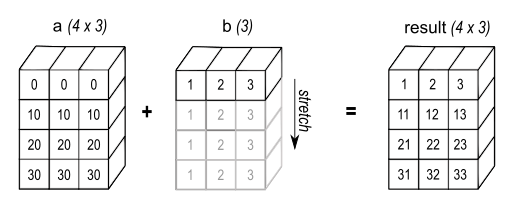

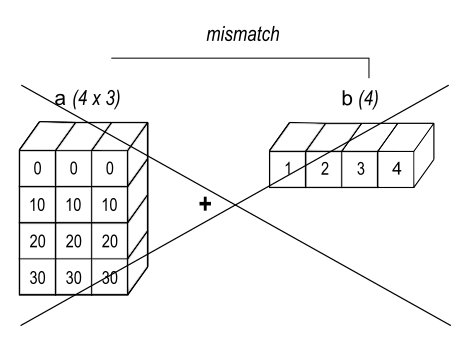

Broadcasting provides a convenient way of taking the outer product (or any other outer operation) of two arrays. The following example shows an outer addition operation of two 1-d arrays:

In [ ]:
import numpy as np
a = np.array([0.0, 10.0, 20.0, 30.0])
b = np.array([1.0, 2.0, 3.0])
a[:, np.newaxis] + b

array([[ 1.,  2.,  3.],
       [11., 12., 13.],
       [21., 22., 23.],
       [31., 32., 33.]])

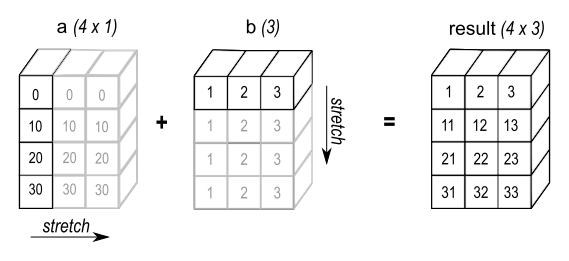

Here the newaxis index operator inserts a new axis into a, making it a two-dimensional 4x1 array. Combining the 4x1 array with b, which has shape (3,), yields a 4x3 array.

# A practical example: vector quantization


Broadcasting comes up quite often in real world problems. A typical example occurs in the vector quantization (VQ) algorithm used in information theory, classification, and other related areas. The basic operation in VQ finds the closest point in a set of points, called codes in VQ jargon, to a given point, called the observation. In the very simple, two-dimensional case shown below, the values in observation describe the weight and height of an athlete to be classified. The codes represent different classes of athletes. [1] Finding the closest point requires calculating the distance between observation and each of the codes. The shortest distance provides the best match. In this example, codes[0] is the closest class indicating that the athlete is likely a basketball player.



In [ ]:
from numpy import array, argmin, sqrt, sum
observation = array([111.0, 188.0])
codes = array([[102.0, 203.0],
               [132.0, 193.0],
               [45.0, 155.0],
               [57.0, 173.0]])
diff = codes - observation    # the broadcast happens here
dist = sqrt(sum(diff**2,axis=-1))
argmin(dist)

np.int64(0)

In this example, the observation array is stretched to match the shape of the codes array:



In [ ]:
# Observation      (1d array):      2
# Codes            (2d array):  4 x 2
# Diff             (2d array):  4 x 2

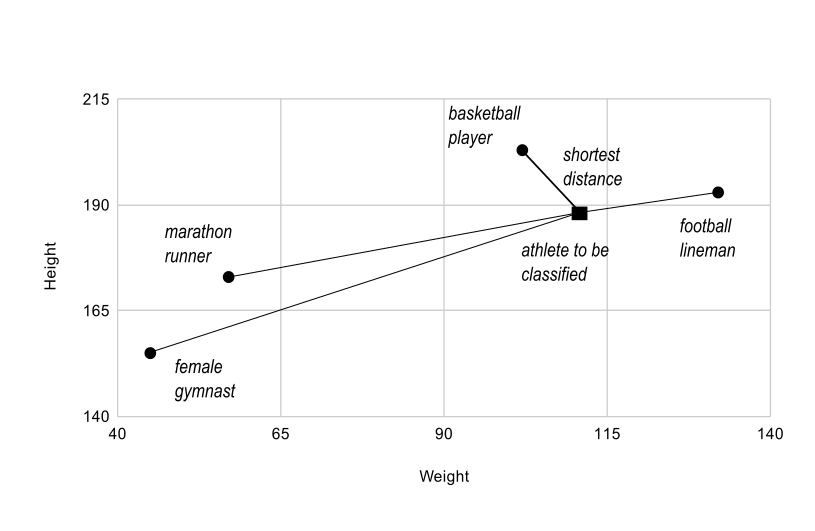

# Advanced indexing and index tricks

NumPy offers more indexing facilities than regular Python sequences. In addition to indexing by integers and slices, as we saw before, arrays can be indexed by arrays of integers and arrays of booleans.

# Indexing with arrays of indices

In [ ]:
a = np.arange(12)**2  # the first 12 square numbers
print(a)
i = np.array([1, 1, 3, 8, 5])  # an array of indices
print(i)
print(a[i])  # the elements of `a` at the positions `i`
j = np.array([[3, 4], [9, 7]])  # a bidimensional array of indices
print(j)
print(a[j])  # the same shape as `j`

[  0   1   4   9  16  25  36  49  64  81 100 121]
[1 1 3 8 5]
[ 1  1  9 64 25]
[[3 4]
 [9 7]]
[[ 9 16]
 [81 49]]


When the indexed array a is multidimensional, a single array of indices refers to the first dimension of a. The following example shows this behavior by converting an image of labels into a color image using a palette.

In [ ]:
palette = np.array([[0, 0, 0],         # black
                    [255, 0, 0],       # red
                    [0, 255, 0],       # green
                    [0, 0, 255],       # blue
                    [255, 255, 255]])  # white
print(palette)
# print(palette.shape)
image = np.array([[0, 1, 2, 0],  # each value corresponds to a color in the palette
                  [0, 3, 4, 0]])
print(image)
# print(image.shape)
palette[image]  # the (2, 4, 3) color image
# image shape: (2, 4)
# Each index maps to a vector of length 3 (RGB)
# Resulting shape: (2, 4, 3)
# That’s why the output is a color image.

[[  0   0   0]
 [255   0   0]
 [  0 255   0]
 [  0   0 255]
 [255 255 255]]
[[0 1 2 0]
 [0 3 4 0]]


array([[[  0,   0,   0],
        [255,   0,   0],
        [  0, 255,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0, 255],
        [255, 255, 255],
        [  0,   0,   0]]])

# Reference

https://numpy.org/

# Exercise 1: Element-wise Mathematical Operation

# Python List Solution

In [ ]:
import random

# Generate large dataset
data_list = [random.random() for _ in range(1_000_000)]

def list_operation(data):
    result = []
    for x in data:
        result.append(3 * x**2 + 2 * x + 1)
    return result

%timeit list_operation(data_list)


211 ms ± 36.9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# Numpy solution

In [ ]:
import numpy as np

data_np = np.random.rand(1_000_000)

def numpy_operation(data):
    return 3 * data**2 + 2 * data + 1

%timeit numpy_operation(data_np)


2.14 ms ± 327 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


# Exercise 2: Mean Normalization

# Python List Solution

In [ ]:
import random
import math

data_list = [random.random() for _ in range(1_000_000)]

def list_normalization(data):
    mean = sum(data) / len(data)
    variance = sum((x - mean) ** 2 for x in data) / len(data)
    std = math.sqrt(variance)

    normalized = []
    for x in data:
        normalized.append((x - mean) / std)
    return normalized

%timeit list_normalization(data_list)


141 ms ± 16.2 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


# NumPy Solution

In [ ]:
import numpy as np

data_np = np.random.rand(1_000_000)
#In real-world ML, this is one feature collected for many samples.
#marks of 1,000,000 students
#blood pressure readings of 1,000,000 patients
#temperature readings recorded over time
# Age	0–100
# Income	10,000–1,000,000
# Blood pressure	80–180
# If we don’t fix this:
# Large numbers dominate distance calculations
# ML models behave poorly
# This operation:
# Centers the data around zero
# Scales the spread to be consistent
# After normalization:
# Mean ≈ 0
# Standard deviation ≈ 1
def numpy_normalization(data):
    return (data - np.mean(data)) / np.std(data)

%timeit numpy_normalization(data_np)


3.1 ms ± 336 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


# Exercise 3: Euclidean Distance

# Python List Solution

In [ ]:
import random
import math

x_list = [random.random() for _ in range(100_000)]
y_list = [random.random() for _ in range(100_000)]

def list_distance(x, y):
    sum_sq = 0
    for i in range(len(x)):
        sum_sq += (x[i] - y[i]) ** 2
    return math.sqrt(sum_sq)

%timeit list_distance(x_list, y_list)


9.61 ms ± 1.4 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


# Numpy solution

In [ ]:
import numpy as np

#how similar are two students/patients etc

x_np = np.random.rand(100_000)
y_np = np.random.rand(100_000)

def numpy_distance(x, y):
    return np.linalg.norm(x - y)

%timeit numpy_distance(x_np, y_np)

61.5 µs ± 14.6 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
